# Analyse av COMPAS-data

Basert på fremgangsmåte gitt i oppgaveteksten

### Importering av biblioteker

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

## a): Les inn og forstå dataene

### Innlesing av data

In [42]:
path = "../data/compas-scores-two-years.csv"
df = pd.read_csv(path, header=0)
print(len(df))
df.head()

7214


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


### Fjerner enkelte rader

Fjerner rader som bryter følgende krav i studien: 

"If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense"

Dette gjøres for å sørge for at anmeldelsen samsvarer med arrestasjonen

In [43]:
df = df[df["days_b_screening_arrest"] <= 30]
df = df[df["days_b_screening_arrest"] >= -30]
print(len(df))

6172


Dette fjerner omtrent 1200 rader

### Forstå hva kolonnene betyr

Bruker kolonnene som ble brukt i ProPublicas analyse.

Forklaringsvariabler:
- "age_cat": Kategorisert alder på personen ved tidspunktet for COMPAS-vurderingen ("Less than 25", "25 - 45", "Greater than 45"). Brukes i stedet for kontinuerlig alder.
- "race": Selvrapportert etnisitet/rasetilhørighet (f.eks. "African-American", "Caucasian"). 
- "sex": Kjønn på personen ("Male" eller "Female").
- "priors_count": Antall tidligere straffbare forhold før COMPAS-vurderingen.
- "c_charge_degree": Alvorlighetsgrad av den nåværende siktelsen. "F" betyr felony (alvorlig lovbrudd), "M" betyr misdemeanor (mindre alvorlig lovbrudd).
- "two_year_recid": Indikatorvariabel (0/1) for om personen begikk en ny straffbar handling innen to år etter COMPAS-vurderingen. Brukes som kontrollvariabel i analysen.

Target: 
- "score_text": COMPAS-algoritmens risikovurdering, kategorisert som "Low", "Medium" eller "High". I analysen slås ofte "Medium" og "High" sammen til én kategori for høy risiko.

### Fjerner kolonnene vi ikke trenger

In [44]:
df = df[["age_cat", "race", "sex", "priors_count", "c_charge_degree", "two_year_recid", "score_text", "decile_score"]].copy()

print(len(df))
df.head()

6172


,age_cat,race,sex,priors_count,c_charge_degree,two_year_recid,score_text,decile_score
0,Greater than 45,Other,Male,0,F,0,Low,1
1,25 - 45,African-American,Male,0,F,1,Low,3
2,Less than 25,African-American,Male,4,F,1,Low,4
5,25 - 45,Other,Male,0,M,0,Low,1
6,25 - 45,Caucasian,Male,14,F,1,Medium,6


### Plots

1. Hvor ofte ulike grupperinger av mennesker (kvinner, menn, hvite og svarte) gjentar forbrytelser

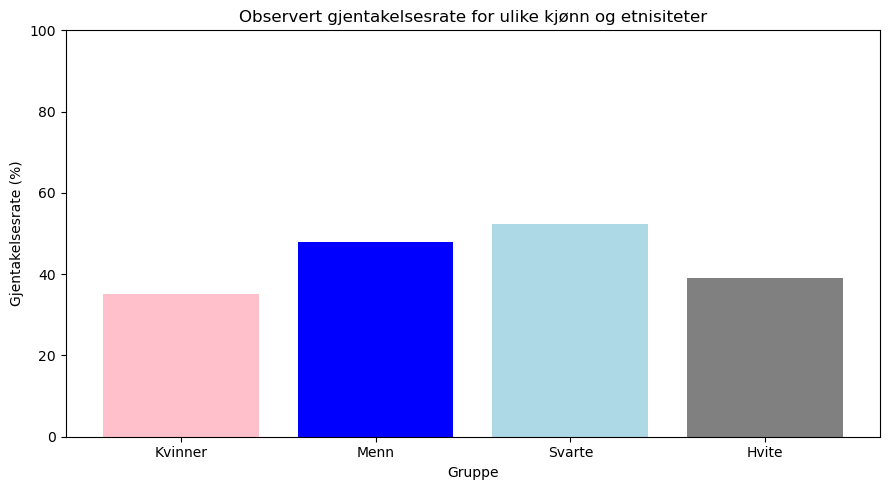

Gjentakelsesrater:
  Kvinner: 35.1%
  Menn: 47.9%
  Svarte: 52.3%
  Hvite: 39.1%


In [45]:
# Gjentakelsesrate per kjønn
gjenta_kjonn = df.groupby("sex")["two_year_recid"].mean() * 100  ### TELLER HVOR MANGE SOM GJENTAR STRAFFBARE HANDLINGER HER (GRUPPERT PÅ KJØNN)
# Gjentakelsesrate per etnisitet
gjenta_etnisitet = df[df["race"].isin(["Caucasian", "African-American"])].groupby("race")["two_year_recid"].mean() * 100. ### TELLER HVOR MANGE SOM GJENTAR STRAFFBARE HANDLINGER HER (GRUPPERT PÅ ETNISITET)

# Slå sammen for samlet figur
labels = ["Kvinner", "Menn", "Svarte", "Hvite"]
values = list(gjenta_kjonn.values) + list(gjenta_etnisitet.values)
colors = ['pink', 'blue', 'lightblue', 'gray']

# Generer plot
plt.figure(figsize=(9, 5))
plt.bar(labels, values, color=colors)
plt.title("Observert gjentakelsesrate for ulike kjønn og etnisiteter")
plt.ylabel("Gjentakelsesrate (%)")
plt.xlabel("Gruppe")
plt.ylim(0, 100)
plt.tight_layout()
#plt.savefig("../figurer/observert_gjentakelsesrate_kjonn_etnisitet.pdf", format="pdf")
plt.show()

print("Gjentakelsesrater:")
for label, value in zip(labels, values):
    print(f"  {label}: {value:.1f}%")


2. Hvor ofte ulike grupperinger av mennesker (kviner, menn, hvite og svarte) blir predikert av algoritmen til å begå straffbare handlinger i fremtiden

Altså: Hvor ofte får ulike grupper score medium eller high. Dette er hva COMPAS predikerer, ikke hvem som faktisk gjentar straffbare handlinger

Vi sier at modellen predikerer gjentakelse hvis score er "medium" eller "high"

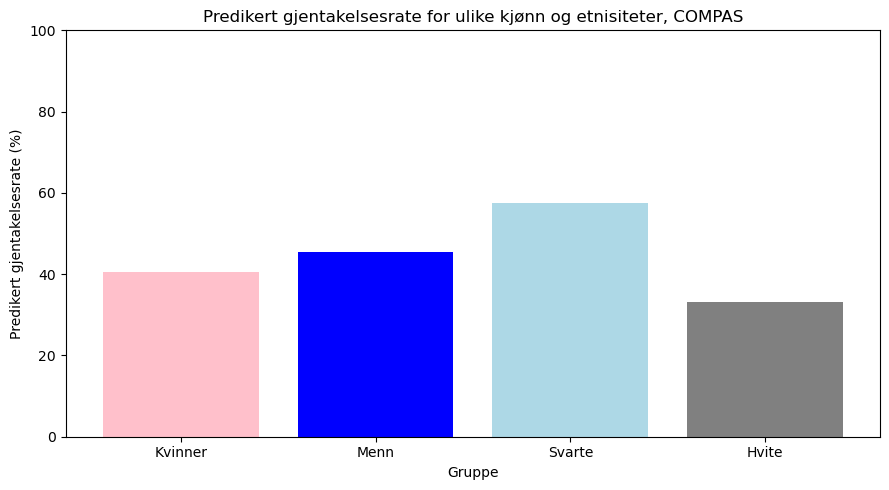

Predikerte gjentakelsesrater:
  Kvinner: 40.5%
  Menn: 45.5%
  Svarte: 57.6%
  Hvite: 33.1%


In [46]:
# Lager kolonne for predikert gjentakelse
df["high_risk"] = df["score_text"] != "Low" ## != betyr "ikke lik", så alle som ikke er "low risk"

# Prediksjonsrate kjønn
pred_kjonn = df.groupby("sex")["high_risk"].mean() * 100
# Prediksjonsrate etnisitet
pred_etnisitet = df[df["race"].isin(["Caucasian", "African-American"])].groupby("race")["high_risk"].mean() * 100

# Slå sammen for samlet figur
labels = ["Kvinner", "Menn", "Svarte", "Hvite"]
values = list(pred_kjonn.values) + list(pred_etnisitet.values)
colors = ['pink', 'blue', 'lightblue', 'gray']

# Generer figur
plt.figure(figsize=(9, 5))
plt.bar(labels, values, color=colors)
plt.title("Predikert gjentakelsesrate for ulike kjønn og etnisiteter, COMPAS")
plt.ylabel("Predikert gjentakelsesrate (%)")
plt.xlabel("Gruppe")
plt.ylim(0, 100)
plt.tight_layout()
# plt.savefig("../figurer/predikert_gjentakelsesrate_kjonn_etnisitet.pdf", format="pdf")
plt.show()
print("Predikerte gjentakelsesrater:")
for label, value in zip(labels, values):
    print(f"  {label}: {value:.1f}%")


3. Hvor ofte ulike grupper fikk ulike risikoskårer

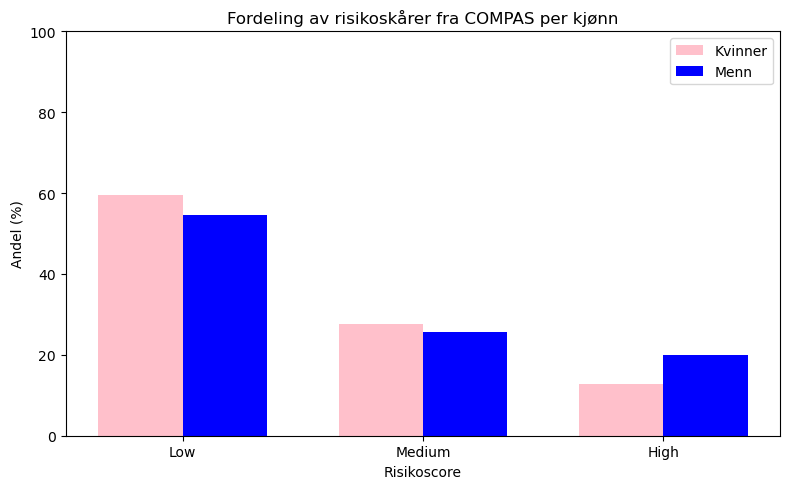

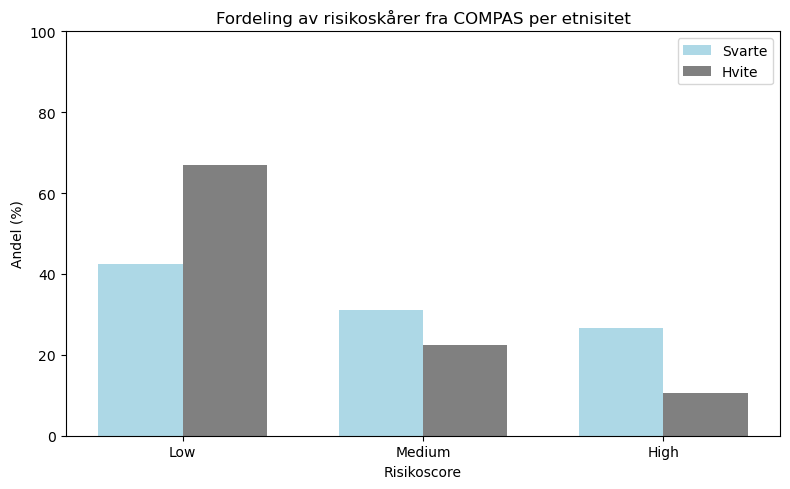

Fordeling av risikoskårer per kjønn:
  Low: Kvinner 59.5%  |  Menn 54.5%
  Medium: Kvinner 27.7%  |  Menn 25.7%
  High: Kvinner 12.9%  |  Menn 19.9%

Fordeling av risikoskårer per etnisitet:
  Low: Svarte 42.4%  |  Hvite 66.9%
  Medium: Svarte 31.0%  |  Hvite 22.5%
  High: Svarte 26.6%  |  Hvite 10.6%


In [47]:
# Fordeling av score_text per kjønn
score_by_sex = pd.crosstab(df['sex'], df['score_text'], normalize='index') * 100
score_by_sex = score_by_sex[['Low', 'Medium', 'High']]  # Sorter kolonner

# Fordeling av score_text per etnisitet
race_df = df[df["race"].isin(["Caucasian", "African-American"])]
score_by_race = pd.crosstab(race_df["race"], race_df["score_text"], normalize="index") * 100

score_by_race = score_by_race[['Low', 'Medium', 'High']]  # Sorter kolonner

# Plot for kjønn
fig, ax = plt.subplots(figsize=(8, 5))
width = 0.35  # Bredde på hver undersøyle
x = np.arange(len(score_by_sex.columns))  # Posisjoner for Low, Medium, High

ax.bar(x - width/2, score_by_sex.loc['Female'], width, label='Kvinner', color='pink')
ax.bar(x + width/2, score_by_sex.loc['Male'], width, label='Menn', color='blue')

ax.set_xlabel('Risikoscore')
ax.set_ylabel('Andel (%)')
ax.set_title('Fordeling av risikoskårer fra COMPAS per kjønn')
ax.set_xticks(x)
ax.set_xticklabels(score_by_sex.columns)
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
# plt.savefig("../figurer/score_fordeling_kjonn_grouped.pdf", format="pdf")
plt.show()

# Plot for etnisitet
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(score_by_race.columns))  # Posisjoner for Low, Medium, High

ax.bar(x - width/2, score_by_race.loc['African-American'], width, label='Svarte', color='lightblue')
ax.bar(x + width/2, score_by_race.loc['Caucasian'], width, label='Hvite', color='gray')

ax.set_xlabel('Risikoscore')
ax.set_ylabel('Andel (%)')
ax.set_title('Fordeling av risikoskårer fra COMPAS per etnisitet')
ax.set_xticks(x)
ax.set_xticklabels(score_by_race.columns)
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
# plt.savefig("../figurer/score_fordeling_etnisitet_grouped.pdf", format="pdf")
plt.show()


print("Fordeling av risikoskårer per kjønn:")
for score in ['Low', 'Medium', 'High']:
    print(f"  {score}: Kvinner {score_by_sex.loc['Female', score]:.1f}%  |  Menn {score_by_sex.loc['Male', score]:.1f}%")

print("\nFordeling av risikoskårer per etnisitet:")
for score in ['Low', 'Medium', 'High']:
    print(f"  {score}: Svarte {score_by_race.loc['African-American', score]:.1f}%  |  Hvite {score_by_race.loc['Caucasian', score]:.1f}%")


4. Hvor ofte de som begikk straffbare handlinger (og de som ikke gjorde det) fikk ulike risikoskårer, og hvordan dette ser ut hvis du kun ser på hvite eller svarte

Deler opp data i de som faktisk gjentok kriminelle handlinger innen 2 år, og de som ikke gjorde det. Ser hvordan risiko-scoren fra COMPAS er fordelt for de to gruppene. Gjør dette for hele datasettet, deretter kun hvite og deretter kun svarte. 

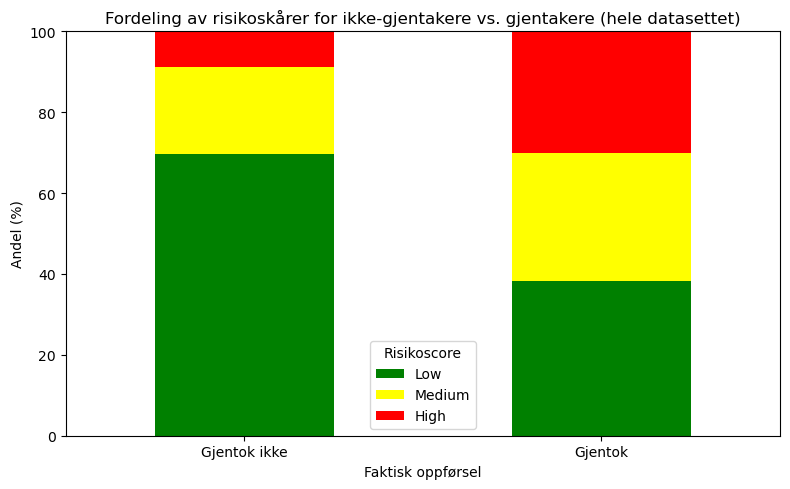

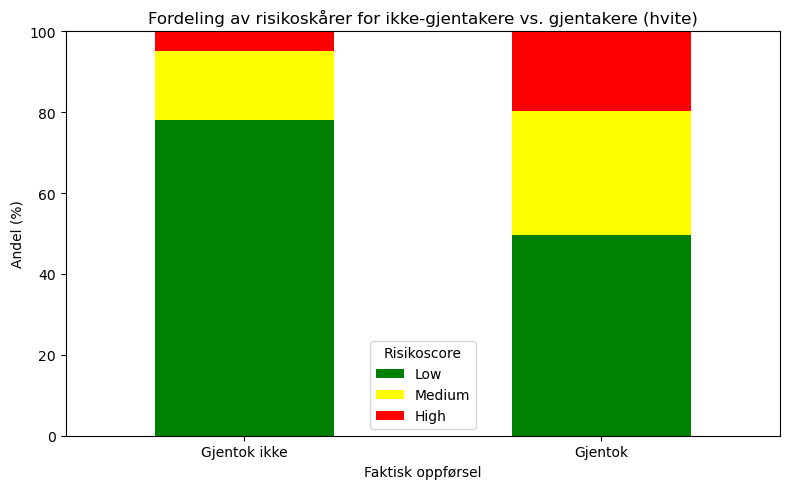

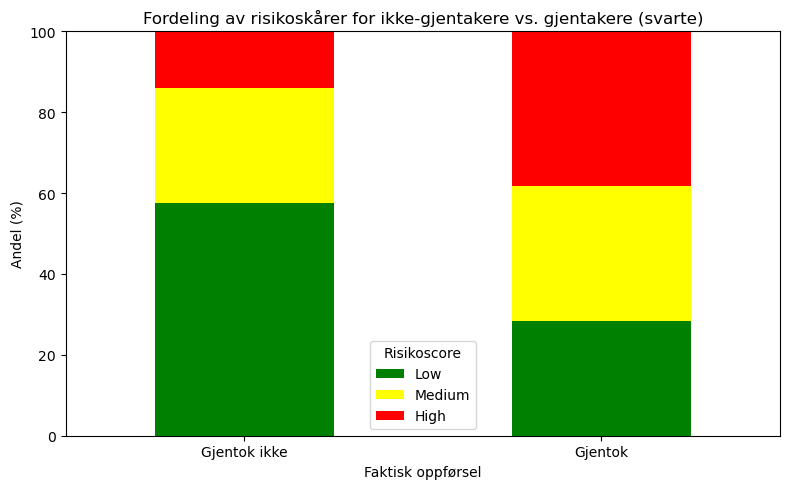


Risikoskårefordeling – Alle:
  Gjentok ikke: Low: 69.7%  |  Medium: 21.4%  |  High: 8.8%
  Gjentok: Low: 38.3%  |  Medium: 31.5%  |  High: 30.2%

Risikoskårefordeling – Hvite:
  Gjentok ikke: Low: 78.0%  |  Medium: 17.3%  |  High: 4.8%
  Gjentok: Low: 49.6%  |  Medium: 30.7%  |  High: 19.7%

Risikoskårefordeling – Svarte:
  Gjentok ikke: Low: 57.7%  |  Medium: 28.4%  |  High: 13.9%
  Gjentok: Low: 28.5%  |  Medium: 33.4%  |  High: 38.2%


In [48]:
# Overall fordeling av score_text per recidivism
overall = pd.crosstab(df['two_year_recid'], df['score_text'], normalize='index') * 100
overall = overall[['Low', 'Medium', 'High']]  
overall.index = ['Gjentok ikke', 'Gjentok']  

# Plot overall
overall.plot(kind='bar', stacked=True, figsize=(8, 5), color=['green', 'yellow', 'red'])
plt.title("Fordeling av risikoskårer for ikke-gjentakere vs. gjentakere (hele datasettet)")
plt.ylabel("Andel (%)")
plt.xlabel("Faktisk oppførsel")
plt.xticks(rotation=0)  
plt.legend(title="Risikoscore")
plt.ylim(0, 100)
plt.tight_layout()
# plt.savefig("../figurer/score_fordeling_gjentakels_alle.pdf", format="pdf")
plt.show()

# For hvite (Caucasian)
white_df = df[df['race'] == 'Caucasian']
white = pd.crosstab(white_df['two_year_recid'], white_df['score_text'], normalize='index') * 100
white = white[['Low', 'Medium', 'High']]
white.index = ['Gjentok ikke', 'Gjentok']

white.plot(kind='bar', stacked=True, figsize=(8, 5), color=['green', 'yellow', 'red'])
plt.title("Fordeling av risikoskårer for ikke-gjentakere vs. gjentakere (hvite)")
plt.ylabel("Andel (%)")
plt.xlabel("Faktisk oppførsel")
plt.xticks(rotation=0)
plt.legend(title="Risikoscore")
plt.ylim(0, 100)
plt.tight_layout()
# plt.savefig("../figurer/score_fordeling_gjentakelse_hvite.pdf", format="pdf")
plt.show()

# For svarte (African-American)
black_df = df[df['race'] == 'African-American']
black = pd.crosstab(black_df['two_year_recid'], black_df['score_text'], normalize='index') * 100
black = black[['Low', 'Medium', 'High']]
black.index = ['Gjentok ikke', 'Gjentok']

black.plot(kind='bar', stacked=True, figsize=(8, 5), color=['green', 'yellow', 'red'])
plt.title("Fordeling av risikoskårer for ikke-gjentakere vs. gjentakere (svarte)")
plt.ylabel("Andel (%)")
plt.xlabel("Faktisk oppførsel")
plt.xticks(rotation=0)
plt.legend(title="Risikoscore")
plt.ylim(0, 100)
plt.tight_layout()
# plt.savefig("../figurer/score_fordeling_gjentakelse_svarte.pdf", format="pdf")
plt.show()

for navn, tabell in [("Alle", overall), ("Hvite", white), ("Svarte", black)]:
    print(f"\nRisikoskårefordeling – {navn}:")
    for gruppe in ['Gjentok ikke', 'Gjentok']:
        scores = "  |  ".join([f"{score}: {tabell.loc[gruppe, score]:.1f}%" for score in ['Low', 'Medium', 'High']])
        print(f"  {gruppe}: {scores}")


### Plotting av Decile scores (tallverdier/prediksjonene til COMPAS)

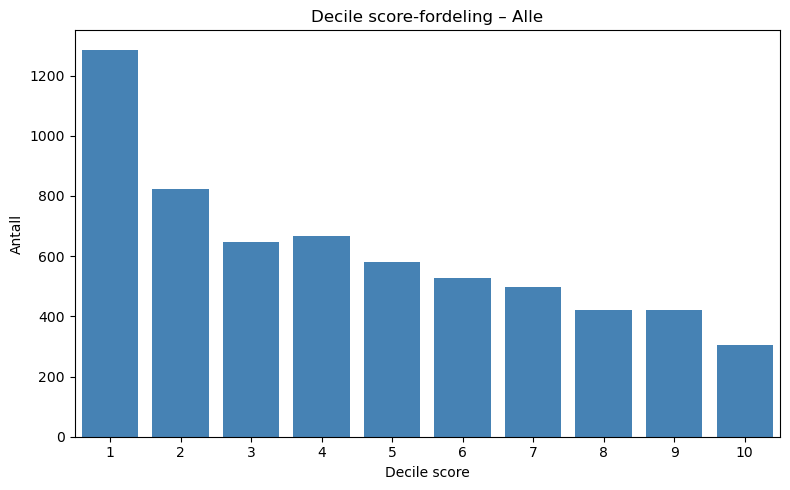

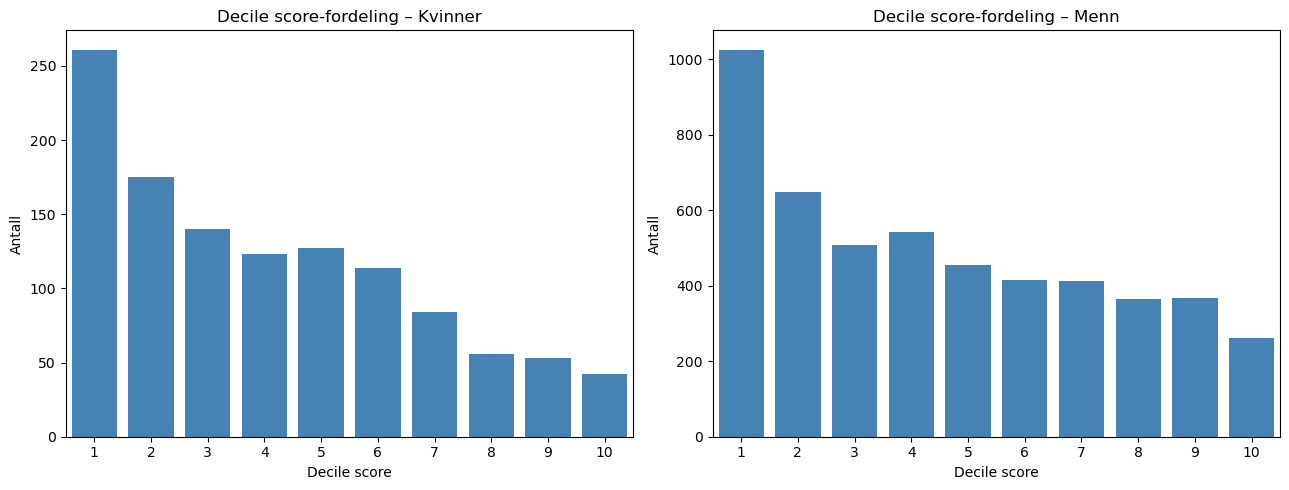

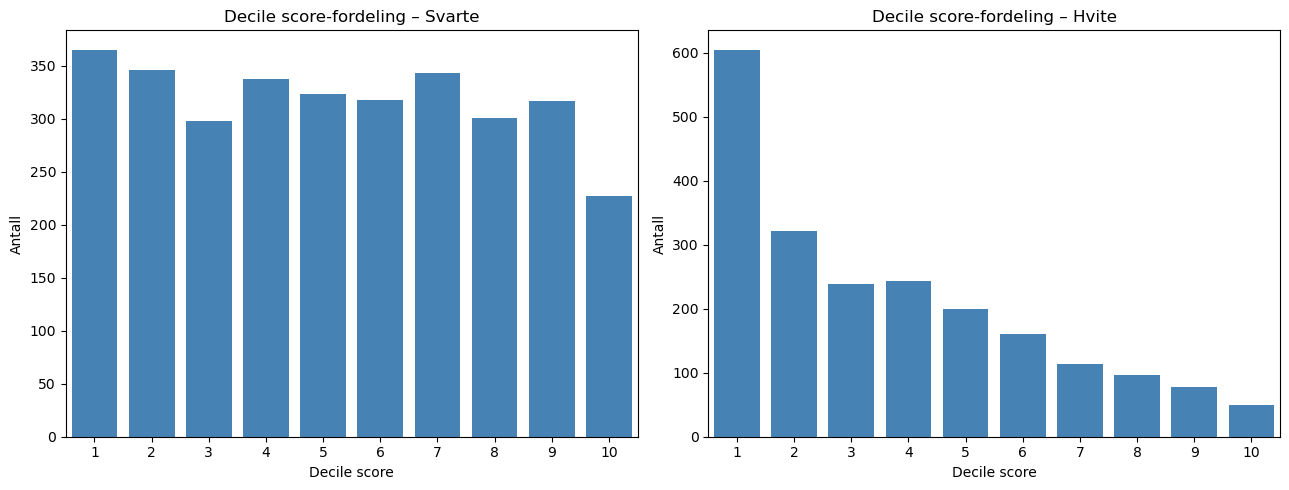

In [73]:
# Figur 1: Alle
fig, ax = plt.subplots(figsize=(8, 5))
counts = df["decile_score"].value_counts().sort_index()
ax.bar(counts.index, counts.values, color="steelblue")
ax.set_title("Decile score-fordeling – Alle")
ax.set_xlabel("Decile score")
ax.set_ylabel("Antall")
ax.set_xticks(range(1, 11))
ax.set_xlim(0.5, 10.5)
plt.tight_layout()
plt.savefig("../figurer/decile_score_fordeling_alle.pdf", format="pdf")
plt.show()

# Figur 2: Kvinner og menn
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (navn, data) in zip(axes, [("Kvinner", df[df["sex"] == "Female"]), ("Menn", df[df["sex"] == "Male"])]):
    counts = data["decile_score"].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="steelblue")
    ax.set_title(f"Decile score-fordeling – {navn}")
    ax.set_xlabel("Decile score")
    ax.set_ylabel("Antall")
    ax.set_xticks(range(1, 11))
    ax.set_xlim(0.5, 10.5)
plt.tight_layout()
plt.savefig("../figurer/decile_score_fordeling_kjonn.pdf", format="pdf")
plt.show()

# Figur 3: Svarte og hvite
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (navn, data) in zip(axes, [("Svarte", df[df["race"] == "African-American"]), ("Hvite", df[df["race"] == "Caucasian"])]):
    counts = data["decile_score"].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="steelblue")
    ax.set_title(f"Decile score-fordeling – {navn}")
    ax.set_xlabel("Decile score")
    ax.set_ylabel("Antall")
    ax.set_xticks(range(1, 11))
    ax.set_xlim(0.5, 10.5)
plt.tight_layout()
plt.savefig("../figurer/decile_score_fordeling_etnisitet.pdf", format="pdf")
plt.show()



## b) Rater

Falske positive, falske negative, sanne positive, sanne negative, positiv prediktiv verdi for:
- Hele befolkningen
- Kvinner
- Menn
- Hvite
- Svarte

Har definerert high_risk kolonne som personer som fikk predikert "High" eller "Medium" 

Sanne positive defineres som de som ble predikert som high_risk og utførte forbrytelse innen to år.

In [50]:
df["high_risk"] = (df["high_risk"]).astype(int)
df.head()

,age_cat,race,sex,priors_count,c_charge_degree,two_year_recid,score_text,decile_score,high_risk
0,Greater than 45,Other,Male,0,F,0,Low,1,0
1,25 - 45,African-American,Male,0,F,1,Low,3,0
2,Less than 25,African-American,Male,4,F,1,Low,4,0
5,25 - 45,Other,Male,0,M,0,Low,1,0
6,25 - 45,Caucasian,Male,14,F,1,Medium,6,1


Funksjon som beregner:
- TP: Sanne positive
- TN: Sanne negative
- FP: Falske positive
- FN: Falske negative
- PPV: Positiv prediktiv verdi


Ratene beregnes ikke av totalt antall observasjoner. Eksempel: FP(rate) = FP / FP + TN
"Av alle faktiske negative, ble så mange feilaktig klassifisert som positive"

In [51]:
def confusion_stats(df):
    TP_tot = int(((df["high_risk"] == 1) & (df["two_year_recid"] == 1)).sum())
    FP_tot = int(((df["high_risk"] == 1) & (df["two_year_recid"] == 0)).sum())
    TN_tot = int(((df["high_risk"] == 0) & (df["two_year_recid"] == 0)).sum())
    FN_tot = int(((df["high_risk"] == 0) & (df["two_year_recid"] == 1)).sum())
    
    TPR = TP_tot / (TP_tot + FN_tot)
    FPR = FP_tot / (FP_tot + TN_tot)
    TNR = TN_tot / (TN_tot + FP_tot)
    FNR = FN_tot / (FN_tot + TP_tot)
    PPV = TP_tot / (TP_tot + FP_tot)
    
    return {
        "TPR": TPR, 
        "FPR": FPR, 
        "TNR": TNR, 
        "FNR": FNR, 
        "PPV": PPV}

Lager dictionary med gruppene som skal itereres over:

In [52]:
groups = {
    "Hele": df,
    "Kvinner": df[df["sex"] == "Female"],
    "Menn": df[df["sex"] == "Male"],
    "Hvite": df[df["race"] == "Caucasian"],
    "Svarte": df[df["race"] == "African-American"],
}

Iterer gjennom groups:

In [53]:
rows = []
for name, data_frame in groups.items():
    stats = confusion_stats(data_frame)
    stats["Group"] = name
    rows.append(stats)

result = pd.DataFrame(rows).set_index("Group")
result

,TPR,FPR,TNR,FNR,PPV
Group,,,,,
Hele,0.616946,0.302706,0.697294,0.383054,0.629953
Kvinner,0.595642,0.301837,0.698163,0.404358,0.516807
Menn,0.620618,0.302960,0.697040,0.379382,0.653626
Hvite,0.503650,0.220141,0.779859,0.496350,0.594828
Svarte,0.715232,0.423382,0.576618,0.284768,0.649535


Tolkning: 
- FPR er høyere for mørke enn for hvite, altså blir mørke oftere feilaktig klassifisert som gjentaker. 
- TNR er lavere for mørke, så de blir mer sjeldens riktig klassifisert som ikke-gjentaker.
- PPV: Sannsynligheten for at man faktisk er positiv, gitt at man ble predikert som positiv (her: positiv=gjentar kriminell handling)

### COMPAS treffsikkerhet

Igjen sier vi at "medium" og "high" betyr at modellen mener personen kommer til å gjenta

In [54]:
compas_pred = (df["score_text"] != "Low").astype(int)
compas_true = df["two_year_recid"]

compas_accuracy = (compas_pred == compas_true).mean()

print(f"Treffsikkerhet til COMPAS: {compas_accuracy:.4f}")
print(f"Treffsikkerhet til COMPAS: {compas_accuracy * 100:.2f}%")


Treffsikkerhet til COMPAS: 0.6607
Treffsikkerhet til COMPAS: 66.07%


## c) Sammenheng med Bayes' setning


Bayes' setning forklarer hvorfor det er en sammenheng mellom presisjon og forskjeller mellom grupper. Hvis vi lar $A$ bety at en person faktisk gjentar kriminalitet innen to år, og $B$ bety at COMPAS gir personen høy risiko, får vi:

$$
P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}
$$

Her er $P(A \mid B)$ den **positive prediktive verdien** (PPV): sannsynligheten for at en person faktisk gjentar kriminalitet gitt at modellen har klassifisert personen som høy risiko.

- $P(B \mid A)$ tilsvarer i praksis **TPR**: andelen av de som faktisk gjentar kriminalitet som COMPAS fanger opp som høy risiko.
- $P(A)$ er **base rate**: hvor vanlig tilbakefall faktisk er i gruppen.
- $P(B)$ er hvor stor andel av gruppen som får prediksjonen høy risiko.

Dette betyr at PPV ikke bare avhenger av hvor god modellen er, men også av hvor høy den faktiske tilbakefallsraten er i gruppen. Hvis to grupper har ulik base rate $P(A)$, vil de derfor kunne få ulik PPV selv om modellen har samme TPR og FPR i begge gruppene.

Det er dette som skaper spenningen mellom ulike rettferdighetsmål. Når grupper har forskjellig tilbakefallsrate i utgangspunktet, er det vanskelig å samtidig ha like feilrater og lik presisjon. Hvis man justerer modellen slik at PPV blir likere mellom gruppene, vil ofte FPR eller FNR bli mer forskjellige. Hvis man i stedet prøver å gjøre feilratene like, vil PPV ofte bli ulik.

I våre resultater ser vi nettopp en slik sammenheng: svarte har høyere TPR, men også høyere FPR, og de har samtidig noe høyere PPV enn hvite. Bayes' setning viser at dette ikke er tilfeldig, men henger sammen med at både base rate og andelen som får høy risiko varierer mellom gruppene. Derfor kan man ikke uten videre kreve at alle disse målene skal være like samtidig.


## d) Undersøke skjevheter i COMPAS

I denne delen av analysen bruker vi Logisisk regresjon for å finne ut av hvilke variabler COMPAS-algoritmen la mest vekt på da den predikerte hvem som gjentar og ikke (eller rettere sagt risikoen for gjentakelse). Vi prøver ikke å lage en modell som faktisk predikerer gjentakelsesrisikoen. Vi vil bare se om COMPAS f. eks forskjellsbehandler ulike grupper. 

### Lag target og kovariat-matrise

Tilsvarende fremgangsmåten til ProPublica

In [55]:
X = df[["age_cat", "race", "sex", "priors_count", "c_charge_degree", "two_year_recid"]]
categorical_cols = ["age_cat", "race", "sex", "c_charge_degree"]
X = pd.get_dummies(X, columns=categorical_cols, prefix=categorical_cols, prefix_sep='_')
X = X.drop(["age_cat_25 - 45", "race_Caucasian", "sex_Male", "c_charge_degree_F"], axis=1)
Y = df["score_text"] != "Low"

In [56]:
X = X.astype(float)
X.head()

,priors_count,two_year_recid,age_cat_Greater than 45,age_cat_Less than 25,race_African-American,race_Asian,race_Hispanic,race_Native American,race_Other,sex_Female,c_charge_degree_M
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
6,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
Y.head()

0    False
1    False
2    False
5    False
6     True
Name: score_text, dtype: bool

### Tilpass Modell

In [58]:
model = LogisticRegression(max_iter=1000)
model.fit(X, Y)
coefs = pd.Series(model.coef_[0], index=X.columns)
coefs


priors_count               0.268390
two_year_recid             0.683852
age_cat_Greater than 45   -1.343841
age_cat_Less than 25       1.300707
race_African-American      0.478172
race_Asian                -0.295296
race_Hispanic             -0.422580
race_Native American       0.842046
race_Other                -0.805964
sex_Female                 0.218082
c_charge_degree_M         -0.309141
dtype: float64

Koeffisientene viser hvor mye hver variabel *dytter* COMPAS-scoren opp eller ned.
Positiv verdi = høyere risikoscore, negativ = lavere. Jo større tall, jo sterkere effekt.

## Viktigste funn

- **Alder slår sterkt ut:** De under 25 år fikk markant høyere score (+1.30), de over 45 år
  markant lavere (−1.34), sammenlignet med midtgruppen (25–45 år). COMPAS vektlegger alder mye.

- **`two_year_recid` (0.68):** Den sterkeste enkeltprediktoren. COMPAS ga høyere score til de
  som faktisk gjentok — det er forventet, og viser at modellen fanger opp noe reelt.

- **`race_African-American` (0.48):** Etter at vi har kontrollert for alder, kjønn, kriminell
  historikk og type lovbrudd, ga COMPAS likevel høyere score til svarte. Dette er kjernen i
  ProPublica-funnet, og tilsvarer at svarte var ~45 % mer sannsynlig å få høy risikoscore enn
  hvite med ellers identisk profil.

- **`priors_count` (0.27):** Flere tidligere lovbrudd gir høyere score — forventet og rimelig.

- **`c_charge_degree_M` (−0.31):** Misdemeanor (mindre alvorlig siktelse) gir lavere score
  enn felony — fornuftig.

## Oppsummert

COMPAS bruker alder og kriminell historikk mye, noe som er rimelig. Men etnisitet spiller
også inn, selv når alt annet er likt — og det er det som er problematisk.


### Undersøk Bias

Henter ut bias-ledd og race_African-American for control:

In [59]:
b = model.intercept_[0]
race_coef = coefs["race_African-American"]

print("Intercept (b):", b)
print("Koeffisient for race_African-American:", race_coef)


Intercept (b): -1.5236276326718823
Koeffisient for race_African-American: 0.4781718010710058


In [60]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

control = sigmoid(b)
print("control =", control)
racialBias = np.exp(race_coef) / (1 - control + control * np.exp(race_coef))
print("racialBias =", racialBias)

print(f"Svarte tiltalte er omtrent {100 * (racialBias - 1):.1f}% mer sannsynlige til å få high risk enn hvite, alt annet likt.")



control = 0.17892795307295556
racialBias = 1.4536502300980352
Svarte tiltalte er omtrent 45.4% mer sannsynlige til å få high risk enn hvite, alt annet likt.


### Partial dependence plot

Samlet figur med alle kovariater:

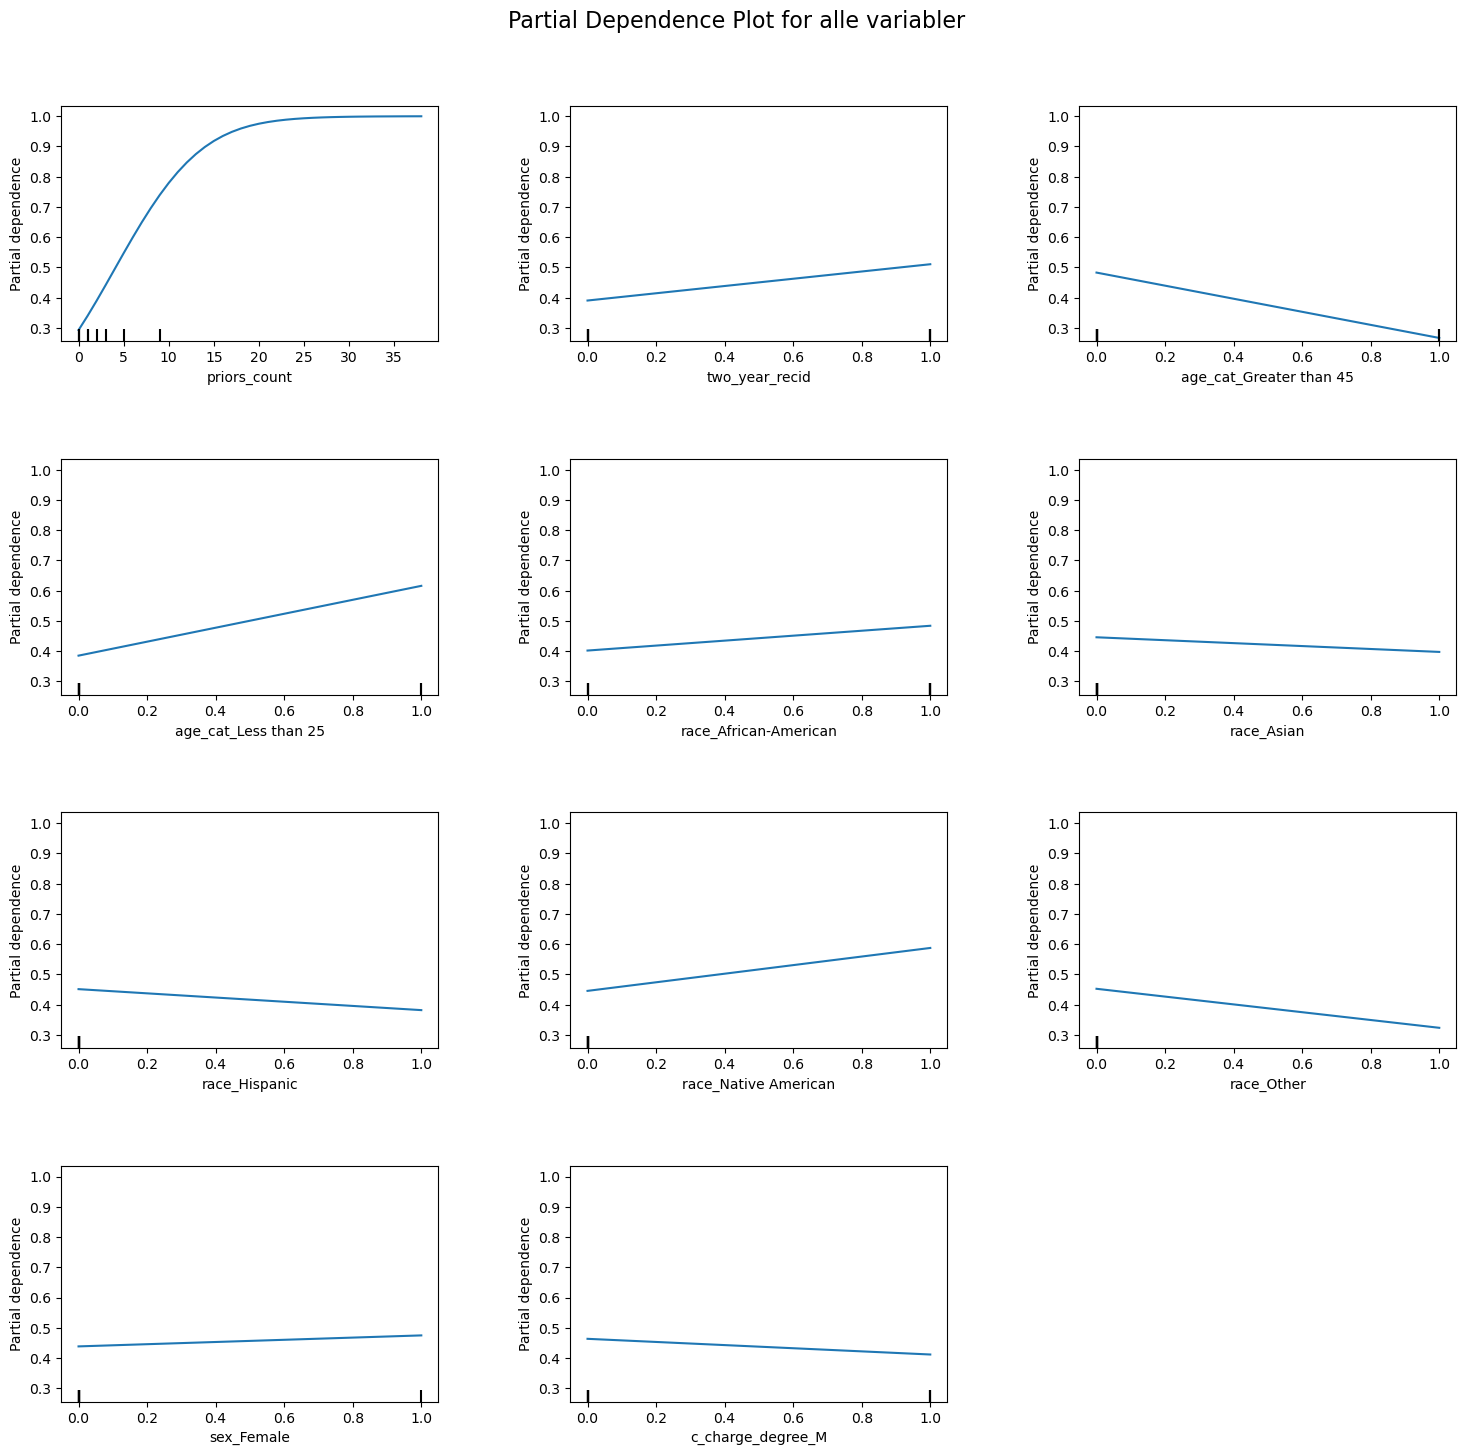

In [61]:
n_features = len(X.columns)
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows))
ax = np.array(ax).reshape(-1)

PartialDependenceDisplay.from_estimator(
    model,
    X,
    features=X.columns.tolist(),
    ax=ax[:n_features],
    grid_resolution=50
)

for extra_ax in ax[n_features:]:
    extra_ax.remove()

fig.suptitle("Partial Dependence Plot for alle variabler", fontsize=16)
plt.subplots_adjust(top=0.92, hspace=0.5, wspace=0.35)
plt.savefig("../figurer/partial_dependence_display_alle_logreg.pdf", format="pdf")


Partial dependence display for "priors_count":

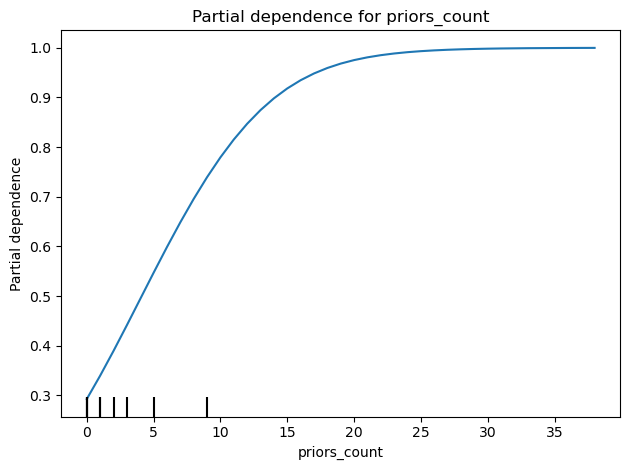

In [62]:
PartialDependenceDisplay.from_estimator(
    model,
    X,
    features=["priors_count"]
)

plt.title("Partial dependence for priors_count")
plt.tight_layout()
plt.savefig("../figurer/partial_dependence_display_priors_logreg.pdf", format="pdf")


## e) Egen modell - Random Forest

I denne delen lager vi vår egen modell — en såkalt random forest — som forsøker å predikere
hvem som faktisk gjentar kriminalitet innen to år. I motsetning til del d), der vi modellerte
COMPAS sine beslutninger, prøver vi her å predikere virkeligheten direkte. Vi utelater
bevisst etnisitet som input, og undersøker om modellen likevel gir systematisk ulike utslag
for hvite og svarte — og om den er mer eller mindre treffsikker enn COMPAS.


### Konstruere kovariat-matrise og target

In [63]:
# Kovariatmatrise uten "race"
X = df[["age_cat", "sex", "priors_count", "c_charge_degree"]]
categorical_cols = ["age_cat", "sex", "c_charge_degree"]
X = pd.get_dummies(X, columns=categorical_cols, prefix=categorical_cols, prefix_sep='_')
X = X.drop(["age_cat_25 - 45", "sex_Male", "c_charge_degree_F"], axis=1)
Y = df["two_year_recid"]


### Gjøre train/test-split

In [64]:
seed = 2704
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=seed)

### Random Forest Model

Finne optimalt antall weak learners. 

In [65]:
weak_learners = [1, 3, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000]
accuracies = []
for n in weak_learners:
    rf = RandomForestClassifier(n_estimators=n, max_features="sqrt",random_state=seed)
    rf.fit(X_train, Y_train)
    accuracies.append(rf.score(X_test, Y_test))

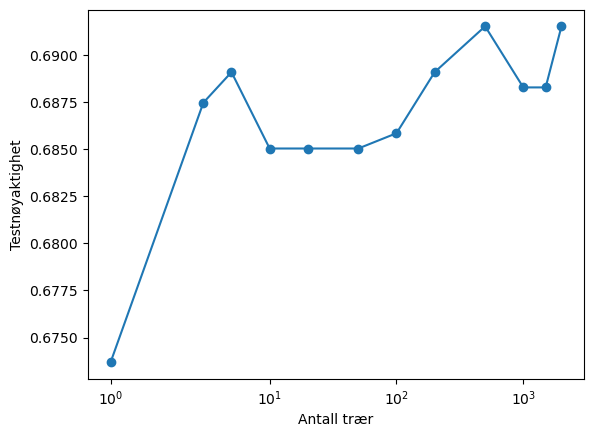

Optimalt antall weak learners: 500
Accuracy score med 500 trær: 0.6915


In [66]:
plt.plot(weak_learners, accuracies, marker="o")
plt.xlabel("Antall trær")
plt.ylabel("Testnøyaktighet")
plt.xscale("symlog")
plt.savefig("../figurer/accuracy_vs_antall_weak_learners.pdf", format="pdf")
plt.show()
opt_ind = np.argmax(accuracies)
print(f"Optimalt antall weak learners: {weak_learners[opt_ind]}")
print(f"Accuracy score med {weak_learners[opt_ind]} trær: {np.round(accuracies[opt_ind], 4)}")

### Velger modell med 500 trær

In [67]:
skog = RandomForestClassifier(n_estimators=500, max_features="sqrt", random_state=seed)
skog.fit(X_train, Y_train)


,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Sammenlikn accuracy score COMPAS og Random Forest

In [68]:
test_df = df.loc[X_test.index].copy()
test_df["compas_pred"] = (test_df["score_text"] != "Low").astype(int)

compas_test_accuracy = (test_df["compas_pred"] == test_df["two_year_recid"]).mean()
forest_accuracy = skog.score(X_test, Y_test)

print(f"Nøyaktighet, COMPAS (testsettet): {compas_test_accuracy * 100:.2f}%")
print(f"Nøyaktighet, Random Forest (testsettet): {forest_accuracy * 100:.2f}%")

Nøyaktighet, COMPAS (testsettet): 68.58%
Nøyaktighet, Random Forest (testsettet): 69.15%


### Sammenlikne falsk positiv-rate osv

In [69]:
# Sammenlikne FPR/FNR for COMPAS og Random Forest på testsettet
test_df["forest_pred"] = skog.predict(X_test)

groups_comparison = {
    "Hele": test_df,
    "Hvite": test_df[test_df["race"] == "Caucasian"],
    "Svarte": test_df[test_df["race"] == "African-American"],
}

rows = []
for group_name, group_data in groups_comparison.items():
    # COMPAS
    compas_data = group_data.copy()
    compas_data["high_risk"] = compas_data["compas_pred"]
    compas_stats = confusion_stats(compas_data)

    # Random Forest
    forest_data = group_data.copy()
    forest_data["high_risk"] = forest_data["forest_pred"]
    forest_stats = confusion_stats(forest_data)

    rows.append({
        "Gruppe": group_name,
        "COMPAS_FPR": compas_stats["FPR"],
        "RF_FPR": forest_stats["FPR"],
        "COMPAS_FNR": compas_stats["FNR"],
        "RF_FNR": forest_stats["FNR"],
        "COMPAS_TPR": compas_stats["TPR"],
        "RF_TPR": forest_stats["TPR"],
        "COMPAS_TNR": compas_stats["TNR"],
        "RF_TNR": forest_stats["TNR"],
        "COMPAS_PPV": compas_stats["PPV"],
        "RF_PPV": forest_stats["PPV"],
    })

result_comparison = pd.DataFrame(rows).set_index("Gruppe")
result_comparison.round(4)


,COMPAS_FPR,RF_FPR,COMPAS_FNR,RF_FNR,COMPAS_TPR,RF_TPR,COMPAS_TNR,RF_TNR,COMPAS_PPV,RF_PPV
Gruppe,,,,,,,,,,
Hele,0.2702,0.2188,0.3682,0.4188,0.6318,0.5812,0.7298,0.7812,0.6554,0.6837
Hvite,0.2253,0.1660,0.5338,0.4865,0.4662,0.5135,0.7747,0.8340,0.5476,0.6441
Svarte,0.3669,0.2857,0.2522,0.3652,0.7478,0.6348,0.6331,0.7143,0.6954,0.7134


In [70]:
# Sammenlikning av falsk positiv-rate og falsk negativ-rate
result_comparison[["COMPAS_FPR", "RF_FPR", "COMPAS_FNR", "RF_FNR"]].round(4)


,COMPAS_FPR,RF_FPR,COMPAS_FNR,RF_FNR
Gruppe,,,,
Hele,0.2702,0.2188,0.3682,0.4188
Hvite,0.2253,0.1660,0.5338,0.4865
Svarte,0.3669,0.2857,0.2522,0.3652


### Analyse av feature importance

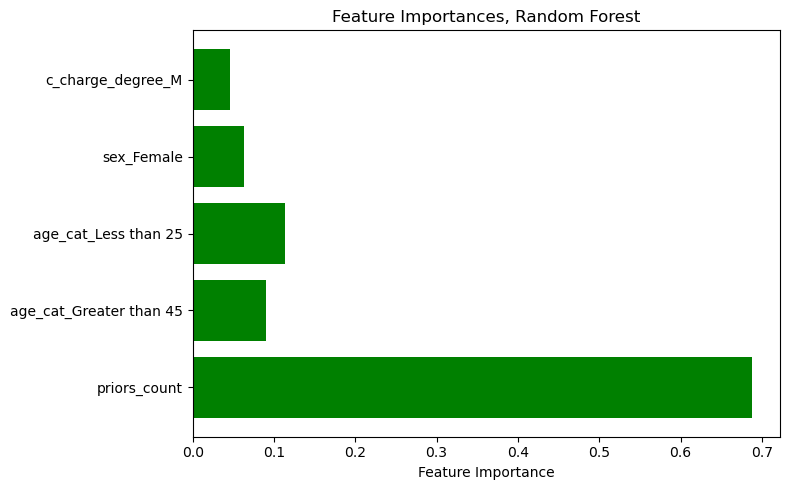

In [71]:
importance = skog.feature_importances_
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(X_train.columns, importance, color="green")
ax.set_xlabel("Feature Importance")
ax.set_title("Feature Importances, Random Forest")
plt.tight_layout()
plt.savefig("../figurer/feature_importance_RF.pdf", format="pdf")
plt.show()


### Tolkning av resultater




Random Forest-modellen fikk noe høyere nøyaktighet enn COMPAS. Samtidig viser sammenligningen av feilratene at modellen ikke nødvendigvis er "bedre" på alle mål. Random Forest har gjennomgående lavere falsk positiv-rate (FPR) enn COMPAS, både totalt og for hvite og svarte. Det betyr at modellen oftere unngår å klassifisere personer som høy risiko når de faktisk ikke gjentar kriminalitet.

Til gjengjeld har Random Forest høyere falsk negativ-rate (FNR) enn COMPAS, særlig for svarte. Det betyr at modellen oftere overser personer som faktisk gjentar kriminalitet. Dette viser at høyere total treffsikkerhet ikke automatisk betyr at modellen er mer rettferdig eller bedre i alle praktiske og etiske forstander.

Forskjellene mellom hvite og svarte er heller ikke borte i Random Forest-modellen, selv om `race` ikke er brukt som input. Det tyder på at andre variabler, som tidligere lovbrudd, alder eller type siktelse, kan fungere som proxyvariabler for etnisitet. Modellen kan derfor fortsatt gi systematisk ulike utslag for ulike grupper.

Feature importance-plottet viser hvilke variabler Random Forest legger mest vekt på. Hvis for eksempel `priors_count` eller `c_charge_degree` får høy betydning, tyder det på at modellen i stor grad bruker disse variablene når den vurderer risiko for tilbakefall. Selv uten eksplisitt bruk av etnisitet kan slike variabler likevel være indirekte knyttet til strukturelle forskjeller i datasettet.

Samlet tyder dette på at modellen vår kan være noe mer presis enn COMPAS målt med vanlig nøyaktighet, men at den fortsatt ikke er åpenbart mer rettferdig. For å vurdere rettferdighet må vi derfor se på flere mål enn bare treffsikkerhet, særlig forskjeller i falske positive og falske negative mellom grupper.